# 基于嵌入层与双层双向 RNN 的 IMDB 情感分类

本 notebook 在词嵌入基础上堆叠 **两层双向 RNN**，同时利用更深网络与双向上下文提升 IMDB 情感分类效果。

In [1]:
import matplotlib as mpl           # Matplotlib 主模块，用于绘图配置
import matplotlib.pyplot as plt     # pyplot：提供类似 MATLAB 的绘图接口
%matplotlib inline
 # Jupyter 魔法命令：将图表直接渲染在 Notebook 中
import numpy as np                  # NumPy：高性能数值计算库
import sklearn                      # Scikit-learn：机器学习工具库（用于 accuracy_score 等）
import pandas as pd                 # Pandas：数据处理与分析库
import os                           # os 模块：操作系统接口（文件/目录操作）
import sys                          # sys 模块：访问 Python 解释器相关信息
import time                         # time 模块：时间相关函数
from tqdm import tqdm          # tqdm：进度条工具，auto 模式自动适配终端/Jupyter
import torch                        # PyTorch 核心模块
import torch.nn as nn               # torch.nn：神经网络模块（层、损失函数等）
import torch.nn.functional as F     # torch.nn.functional：无参数的函数式 API（激活函数、损失等）

# 打印 Python 版本信息
print(sys.version_info)
# 打印各依赖库的版本，便于复现实验环境
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

# 优先使用 GPU（cuda:0），若不可用则退回 CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)  # 打印当前使用的设备

seed = 42  # 随机种子，用于保证实验可复现性


sys.version_info(major=3, minor=14, micro=5, releaselevel='final', serial=0)
matplotlib 3.10.9
numpy 2.4.6
pandas 3.0.3
sklearn 1.9.0
torch 2.12.0+cu132
cuda:0


## 一、加载 IMDB 数据集

本节通过 HuggingFace `datasets` 库加载 [stanfordnlp/imdb](https://huggingface.co/datasets/stanfordnlp/imdb) 数据集。该数据集包含 **50 000** 条英文电影评论，已划分为训练集 25 000 条、测试集 25 000 条；每条样本包含原始文本 `text` 与情感标签 `label`（0 = 负面，1 = 正面）。与 Keras 预处理后版本不同，此处保留**原始字符串**，便于后续自定义分词与词典构建。

### 1.1 从 HuggingFace 下载并缓存数据集

使用 `load_dataset` 接口自动下载数据到本地 `cache_dir`，避免重复联网。返回值为 `DatasetDict` 类型，可通过键名 `'train'`、`'test'` 访问各子集。

In [2]:
from datasets import load_dataset  # HuggingFace datasets 库：提供 load_dataset 统一数据加载接口

cache_dir = 'data/imdb'  # str：本地缓存目录路径，下载后的 Arrow 文件将保存在此

if not os.path.exists(cache_dir):  # os.path.exists(path) -> bool：判断目录是否已存在
    os.makedirs(cache_dir)  # os.makedirs(path)：递归创建目录（含父目录），已存在时不报错

# load_dataset(name, cache_dir) -> DatasetDict
#   name: 数据集标识符，'stanfordnlp/imdb' 为 Stanford NLP 发布的 IMDB 影评数据集
#   cache_dir: 指定缓存位置，第二次运行将直接读取本地文件，无需重新下载
dataset = load_dataset('stanfordnlp/imdb', cache_dir=cache_dir)

print(type(dataset))  # 预期输出 <class 'datasets.dataset_dict.DatasetDict'>，类似字典，键为 split 名
print(type(dataset['train']['text']))  # 预期输出 Column 类型，存储该列所有文本，支持索引访问

<class 'datasets.dataset_dict.DatasetDict'>
<class 'datasets.arrow_dataset.Column'>


### 1.2 提取训练集与测试集的文本和标签

将 `DatasetDict` 中各 split 的 `text`、`label` 列转为 NumPy 一维数组，便于后续向量化处理与批训练。`label` 为整数 0（负面）或 1（正面）。

In [3]:
# np.array(iterable) -> ndarray：将 Column / 列表转为 NumPy 数组，dtype 由元素类型自动推断
train_texts = np.array(dataset['train']['text'])    # shape=(25000,)，元素为 str，训练集评论原文
train_labels = np.array(dataset['train']['label'])  # shape=(25000,)，元素为 int64，取值 0 或 1
test_texts = np.array(dataset['test']['text'])      # shape=(25000,)，测试集评论原文
test_labels = np.array(dataset['test']['label'])    # shape=(25000,)，测试集情感标签

## 二、构造 word2idx 和 idx2word

在自然语言处理中，模型只能处理数值输入，因此需要将单词映射为整数索引。本节基于**训练集**统计词频、构建有限大小的词典，并预留特殊符号：`<PAD>`（填充）、`<OOV>`（未登录词）、`<BOS>`（句首）、`<EOS>`（句尾）。测试集中未出现在训练词典里的词将统一映射为 `<OOV>`。

### 2.1 文本清洗与分词

对训练文本做简单规范化：将标点替换为空格、合并连续空白，再按空格切分为词列表。仅在训练集上统计词频，避免测试集信息泄露。

In [4]:
from collections import Counter  # Counter：可哈希元素的可变映射，专门用于词频统计；most_common(n) 按频率降序返回最高频 n 项

import re  # re：正则表达式模块，用于复杂字符串模式匹配与替换

def clean_text(text):
    """
    对单条评论做轻量文本清洗。

    参数:
        text (str): 原始电影评论字符串。

    返回:
        str: 清洗后的文本，首尾无多余空白，词与词之间以单个空格分隔。
    """
    text = text.replace(',', ' ').replace('.', ' ')  # 将逗号、句号替换为空格，弱化标点对分词的影响
    text = re.sub(r'\s+', ' ', text)  # re.sub(pattern, repl, s)：将连续空白（空格/换行/制表符）合并为一个空格
    return text.strip()  # str.strip()：去除首尾空白字符，返回新字符串

# 列表推导式：对 train_texts 中每条评论调用 clean_text，再封装为 NumPy 数组
train_texts = np.array([clean_text(t) for t in train_texts])  # shape 仍为 (25000,)，元素为清洗后的 str
test_texts= np.array([clean_text(t) for t in test_texts])   #测试集数据也清洗

all_words = []  # list[str]：存放训练集全部分词结果，用于后续统计词频
for text in train_texts:  # 遍历每条清洗后的评论
    all_words.extend(text.split())  # str.split()：默认按任意空白切分，返回 list[str]；extend 将词追加到 all_words

word_counts = Counter(all_words)  # Counter(all_words) -> Counter：键为单词，值为出现次数

### 2.2 构建 word2idx 与 idx2word 映射

选取词频最高的若干词填入词典（索引从 4 起），并建立反向映射 `idx2word`，便于将整数索引还原为可读单词。超出词典容量的词在编码阶段将映射为 `<OOV>`（索引 1）。

In [5]:
max_vocab_size = 20000  # int：词典总容量上限（含 4 个特殊符号），Embedding 层 num_embeddings 将与此一致

# dict[str, int]：词 -> 索引；索引 0~3 预留给特殊 token，普通词从 4 开始编号
word2idx = {'<PAD>': 0, '<OOV>': 1, '<BOS>': 2, '<EOS>': 3}

# Counter.most_common(n) -> list[tuple[str, int]]：返回频率最高的 n 个 (词, 次数) 元组
# 排序规则：按词频降序（出现次数多的在前，少的在后），频率相同时按首次出现顺序排列
most_common_words = word_counts.most_common(max_vocab_size - 4)  # 预留 4 个位置给特殊符号；列表首项为最高频词

start = 4  # int：普通词汇索引起始值（0~3 已被特殊符号占用）
for idx, (word, count) in enumerate(most_common_words, start=start):
    # enumerate(iterable, start)：同时产出索引 idx 与元素 (word, count)
    # 因 most_common 为降序，idx=4 对应最高频词，idx 越大对应词频越低
    word2idx[word] = idx  # 将高频词写入正向词典，idx 从 4 递增到 max_vocab_size - 1

print(f"词典大小: {len(word2idx)}")  # len(dict) -> int：当前词典中的条目总数

# 字典推导式：由 word2idx 反转得到 idx2word，键为 int 索引，值为 str 单词
idx2word = {idx: word for word, idx in word2idx.items()}  # dict[int, str]

vocab_size = len(word2idx)  # int：词典条目总数，供后续 Embedding 层 num_embeddings 使用

for i in range(10):  # 打印前 10 个索引对应的词，验证特殊符号与普通词编号是否正确
    print(f"{i}: {idx2word[i]}")  # 预期 0~3 为 <PAD>/<OOV>/<BOS>/<EOS>，4 起为高频实词

词典大小: 20000
0: <PAD>
1: <OOV>
2: <BOS>
3: <EOS>
4: the
5: a
6: and
7: of
8: to
9: is


## 三、分析数据长度分布

统计训练集中各评论的单词数（序列长度），可视化其分布，并确定截断/填充的最大长度 `MAX_LENGTH`。

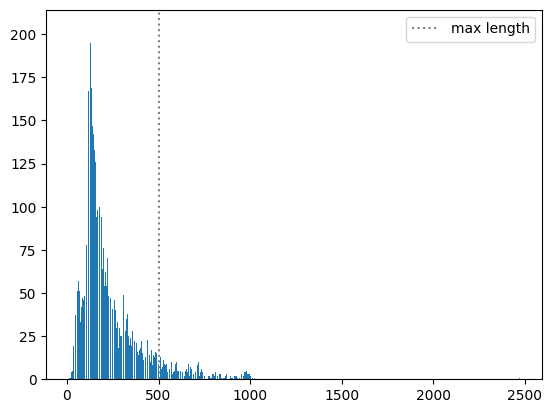

In [6]:
# 选择合适的最大序列长度（max_length）
length_collect = {}  # 用字典存储 {序列长度: 出现次数} 的频率统计

# 遍历训练集中每条评论，统计其长度出现次数
for text in train_texts:
    length = len(text.split())                                       # 获取当前评论的单词数（序列长度）
    length_collect[length] = length_collect.get(length, 0) + 1  # 累计该长度出现次数

# 设置最大序列长度——超过此长度的评论将被截断，短于此长度的将被填充（Padding）
MAX_LENGTH = 500

# 绘制各长度频率的柱状图，横轴为序列长度，纵轴为出现次数
plt.bar(length_collect.keys(), length_collect.values())
# 在 MAX_LENGTH=500 处绘制竖虚线，直观展示截断位置（绝大多数评论长度在 500 以内）
plt.axvline(MAX_LENGTH, label="max length", c="gray", ls=":")
plt.legend()  # 显示图例
plt.show()    # 渲染图表

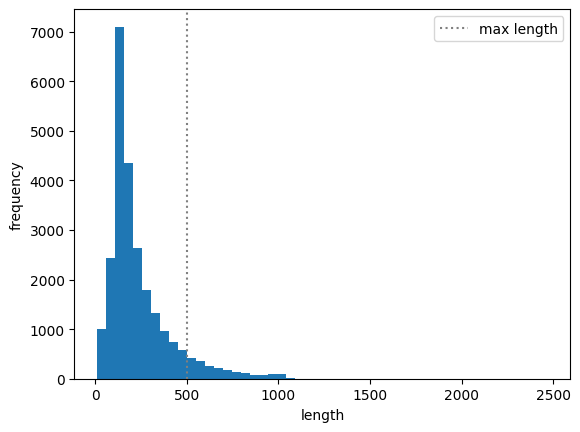

In [7]:
# 用直方图更直观地展示句子长度分布（bins=50 将范围分为 50 个区间）
# 列表推导式：提取每条评论的单词数，生成长度列表
length_list = [len(text.split()) for text in train_texts]  # List[int]，每个元素为对应评论的长度

# 绘制长度分布直方图
plt.hist(length_list, bins=50)       # bins=50：将长度范围均分为 50 个区间
plt.xlabel("length")                 # 横轴：序列长度（单词数）
plt.ylabel("frequency")              # 纵轴：出现频次
plt.axvline(500, label="max length", c="gray", ls=":")  # 在 500 处画竖虚线标注截断点
plt.legend()                         # 显示图例
plt.show()                           # 渲染图表

### 3.1 查看前 10 条样本的长度

In [8]:
# 查看前 10 条训练样本的序列长度
# 返回值：List[int]，例如 [292, 214, 96, ...]
# 可以看到不同评论的长度差异很大，因此需要 Padding 将其统一到相同长度
length_list[0:10]

[292, 214, 96, 121, 325, 123, 114, 303, 486, 224]

In [9]:
# 构造一个用于演示 Tokenizer 功能的原始文本列表（批量输入格式）
# 每个元素都是 List[str]（分词后的单词列表），模拟真实 NLP 管道中的批次数据
raw_text = [
    "hello world".split(),               # 样本 1：["hello", "world"]
    "tokenize text datas with batch".split(),  # 样本 2：5 个单词
    "this is a test".split()             # 样本 3：4 个单词
]
raw_text  # 打印查看批次原始文本结构

[['hello', 'world'],
 ['tokenize', 'text', 'datas', 'with', 'batch'],
 ['this', 'is', 'a', 'test']]

## 四、Tokenizer

封装一个 `Tokenizer` 类，实现 **编码（Encode）** 和 **解码（Decode）** 两大核心功能：
- **Encode**：将原始文本批次转换为填充后的整数 id 张量
- **Decode**：将整数 id 序列还原为可读文本

**RNN 注意**：

1. **前缀填充**：RNN 应使用 `padding_first=True`。RNN 按时间步递推隐藏状态，若 PAD 放在句末，真实词处理完后 PAD 仍会不断改写已积累的语义，使句末表示被稀释；PAD 放在句首时，有效词依次递推，最后时间步停在句末真实词上，语义保留更完整。

2. **双向句向量取值（易错点）**：双向时 **不能** 直接用 `seq_output[:, -1, :]` 作为句向量。PyTorch 中位置 `t` 的反向输出表示「从句末倒读到 `t`」的信息，因此在末位置 `-1` 反向只看过最后一个词；反向读完整句的状态在首位置 `0`。

   **等价写法（末层、双向）**：
   - 写法 A：`torch.cat([final_hidden[-2], final_hidden[-1]], dim=-1)`
   - 写法 B：`torch.cat([seq_output[:, -1, :h], seq_output[:, 0, h:]], dim=-1)`（`h = rnn.hidden_size`）
   - 两种写法数学等价；A 更直观，B 便于理解 `seq_output` 各时间步含义。

3. **双层 RNN 的 `final_hidden` 索引**（`num_layers=2, bidirectional=True` 时共 4 行）：
   - `final_hidden[0/1]`：第 0 层正/反向（中间层，一般不直接用于分类）
   - `final_hidden[2/3]`：第 1 层正/反向（末层，句向量来源）
   - 通式：末层正向 `final_hidden[2*L-2]`，末层反向 `final_hidden[2*L-1]`
   - `seq_output` 仅含**最后一层**逐步输出，不含第 0 层中间结果。

4. **单向句向量等价写法**（任意层数）：
   - `final_hidden[-1]` ≡ `seq_output[:, -1, :]`

In [10]:
class Tokenizer:
    def __init__(self, word2idx, idx2word, max_length=500,
                 pad_idx=0, bos_idx=2, eos_idx=3, unk_idx=1,
                 truncate_mode='adaptive'):
        """
        初始化 Tokenizer（文本编解码器）
        参数：
            word2idx       (Dict[str,int]): 单词 → id 映射字典
            idx2word       (Dict[int,str]): id → 单词 映射字典
            max_length     (int):           序列最大长度，超出则按 truncate_mode 处理，默认 500
            pad_idx        (int):           填充 token 的 id，默认 0
            bos_idx        (int):           句子起始 token 的 id，默认 2
            eos_idx        (int):           句子结束 token 的 id，默认 3
            unk_idx        (int):           未知词 token 的 id，默认 1
            truncate_mode  (str):           超长序列截断策略，默认 'adaptive'
                - 'adaptive'：自适应步长，在全文上等间隔采样 max_length 个 token
                - 'head'    ：保留句首，丢弃末尾（index[:max_length]）
                - 'tail'    ：保留句尾，丢弃开头（index[-max_length:]）
        """
        self.word2idx       = word2idx        # 单词 → id 字典，用于编码
        self.idx2word       = idx2word        # id → 单词 字典，用于解码
        self.max_length     = max_length      # 序列截断/填充的最大长度
        self.pad_idx        = pad_idx         # 填充符 id
        self.bos_idx        = bos_idx         # 句子起始符 id
        self.eos_idx        = eos_idx         # 句子结束符 id
        self.unk_idx        = unk_idx         # 未知词 id
        valid_modes = ('adaptive', 'head', 'tail')  # 允许的截断策略枚举
        if truncate_mode not in valid_modes:
            raise ValueError(f"truncate_mode 必须是 {valid_modes} 之一，当前为 {truncate_mode!r}")
        self.truncate_mode  = truncate_mode   # str：超长序列截断策略

    def _truncate_to_max_length(self, index, max_length):
        """
        将超长 id 序列压缩到 max_length（仅当 len(index) >= max_length 时调用）
        参数：
            index      (List[int]): 单条样本的 token id 列表
            max_length (int):       目标序列长度
        返回：
            List[int]，长度恒为 max_length
        """
        if self.truncate_mode == 'head':
            return index[:max_length]  # 保留句首 max_length 个 token，丢弃末尾
        if self.truncate_mode == 'tail':
            return index[-max_length:]  # 保留句尾 max_length 个 token，丢弃开头
        # adaptive：步长 step ≈ len(index) / max_length，在 [0, len-1] 上等间隔采样
        positions = np.linspace(0, len(index) - 1, max_length, dtype=int)  # ndarray[int]，形状 (max_length,)
        return [index[i] for i in positions]  # List[int]，兼顾首尾与中间信息

    def encode(self, text_list, padding_first=False):
        """
        将文本列表批量编码为整数 id 张量
        参数：
            text_list      (List[List[str]]): 每条文本已拆分为单词列表
            padding_first  (bool):           True 时前缀填充（PAD 在序列头部，避免 RNN 递推时句末语义被 PAD 稀释）；
                                             False 时后缀填充（PAD 在序列尾部，适合池化/CNN 等不依赖最后时间步的模型）
        返回：
            torch.Tensor，形状 (batch_size, seq_len)，dtype=torch.long
        """
        # 动态确定本批次的序列长度（取最长句，但不超过 max_length）
        max_length = min(self.max_length, max(
            [len(text) for text in text_list]))

        indices = []
        for text in text_list:
            index = [self.word2idx.get(word, self.unk_idx) for word in text]  # 单词 → id
            if len(index) < max_length:
                pad_len = max_length - len(index)  # int：需要补充的 PAD 个数
                if padding_first:
                    index = [self.pad_idx] * pad_len + index  # 前缀填充：PAD 在前，有效词靠后，避免句末语义被稀释
                else:
                    index = index + [self.pad_idx] * pad_len  # 后缀填充：PAD 追加在序列尾部
            else:
                index = self._truncate_to_max_length(index, max_length)  # 按 truncate_mode 处理超长序列
            indices.append(index)
        return torch.tensor(indices)  # List[List[int]] → 2D Tensor

    def decode(self, indices_list, remove_pad=True, split=False):
        """
        将整数 id 序列还原为文本
        参数：
            indices_list (List[List[int]]): 每条样本的 id 序列
            remove_pad   (bool): 是否跳过 PAD ，默认 True（前缀 PAD 跳过，后缀 PAD 遇则停止）
            split        (bool): False 返回字符串；True 返回单词列表
        返回：List[str] 或 List[List[str]]
        """
        text_list = []
        for indices in indices_list:
            text = []
            for index in indices:
                word = self.idx2word.get(index, "<UNK>")  # id → 单词
                if remove_pad and word == "<PAD>":
                    if text:  # 已有有效词后遇到 PAD，说明是后缀填充，停止解码
                        break
                    continue  # 跳过前缀 PAD
                text.append(word)
            text_list.append(" ".join(text) if not split else text)
        return text_list


# 实例化 Tokenizer；truncate_mode 可选 'adaptive'（默认）、'head'、'tail'
tokenizer = Tokenizer(word2idx=word2idx, idx2word=idx2word, truncate_mode='adaptive')

# 测试示例文本的编码效果（RNN 使用 padding_first=True，前缀填充以保留句末有效语义）
raw_text = ["hello world".split(),
            "tokenize text datas with batch".split(),
            "this is a test".split()]
indices = tokenizer.encode(raw_text, padding_first=True)  # encode 支持批量处理与前缀填充

print("raw text:")  # 打印原始文本
for raw in raw_text:
    print(raw)
print("\n")
print("indices:")   # 打印编码后的 id 张量
for index in indices:
    print(index)
print("\n")


raw text:
['hello', 'world']
['tokenize', 'text', 'datas', 'with', 'batch']
['this', 'is', 'a', 'test']


indices:
tensor([    0,     0,     0, 14989,   229])
tensor([   1, 3166,    1,   19,    1])
tensor([   0,   14,    9,    5, 2429])




In [11]:
# 演示 decode：将编码后的 id 张量还原为文本
# remove_bos/eos/pad 均设为 False，可看到特殊 token 的位置
decode_text = tokenizer.decode(indices.tolist())  # 保留填充符 [PAD]
print("decode text----------")
for decode in decode_text:
    print(decode)  # 每行为一条解码文本


decode text----------
hello world
<OOV> text <OOV> with <OOV>
this is a test


## 五、数据集与 DataLoader

封装 `IMDBDataset` 与 `collate_fct`，将 Tokenizer 编码集成到数据加载流程中。

In [12]:
from torch.utils.data import Dataset, DataLoader
# Dataset：自定义数据集基类，需实现 __len__ 和 __getitem__
# DataLoader：批量数据加载器


class IMDBDataset(Dataset):
    def __init__(self, data, labels):
        """
        参数：
            data          (np.ndarray): 样本文本数组（每个元素为str）
            labels        (np.ndarray): 情感标签数组（0 或 1）
        """
        self.data = data      # 样本文本数组
        self.labels = labels  # 标签数组

    def __getitem__(self, index):
        """按索引取一条样本，返回 (text: str, label: int)"""
        text  = self.data[index]
        label = self.labels[index]
        return text, label

    def __len__(self):
        """返回数据集样本总数（int）"""
        return len(self.data)


def collate_fct(batch):
    """
    DataLoader 的自定义整理函数（collate function）
    将一个 batch 的样本转换为 Tensor，同时完成 Tokenizer 编码。
    参数：
        batch (List[Tuple[str, int]]): 每个元素为 (文本字符串, 标签整数 0/1)
    返回：
        text_tensor  (Tensor): 形状 (batch_size, seq_len)，dtype=torch.int32，供 Embedding 层输入
        label_tensor (Tensor): 形状 (batch_size, 1)，dtype=torch.float32，供 BCE 损失计算
    说明（标签维度变换的必要性）：
        - label_list 经 torch.tensor 后默认形状为 (batch_size,)，是一维向量
        - 本模型最后一层 nn.Linear(hidden_dim, 1)，输出 logits 形状为 (batch_size, 1)
        - F.binary_cross_entropy_with_logits 要求 input 与 target 形状一致，故需 reshape(-1, 1)
        - 其中 -1 表示自动推断 batch 维大小；-1 维的 1 表示二分类仅有 1 个输出 logit
        - .to(dtype=torch.float) 将整数标签 0/1 转为浮点 0.0/1.0，满足 BCE 对 target 类型的要求
    """
    text_list  = [item[0].split() for item in batch]  # List[List[str]]：将每条文本按空格拆成单词列表
    label_list = [item[1] for item in batch]           # List[int]：提取本 batch 的情感标签（0=负面，1=正面）
    # padding_first=True：前缀填充，避免 RNN 在句末 PAD 上递推稀释有效语义，最后时间步对应句末真实词
    text_list  = tokenizer.encode(text_list, padding_first=True).to(dtype=torch.int)  # Tensor(batch_size, seq_len)
    label_tensor = torch.tensor(label_list)            # Tensor(batch_size,)：列表 → 一维张量，形状如 (64,)
    label_tensor = label_tensor.reshape(-1, 1)         # Tensor(batch_size, 1)：升维为二维，与模型 logits 形状对齐
    label_tensor = label_tensor.to(dtype=torch.float)  # Tensor(batch_size, 1), float32：供 binary_cross_entropy_with_logits 使用
    return text_list, label_tensor                     # 返回 (文本张量, 标签张量) 元组，供训练循环解包


# 实例化训练集和测试集
train_ds = IMDBDataset(train_texts,train_labels)  # 训练集：25000 条
test_ds  = IMDBDataset(test_texts,  test_labels)   # 测试集：25000 条


In [13]:
batch_size = 64  # 每个 mini-batch 的样本数

# 训练集 DataLoader：每轮打乱顺序（shuffle=True），防止模型记住样本顺序
# collate_fn 指定自定义整理函数，将字符串列表转为 Tensor
train_dl = DataLoader(train_ds, batch_size=batch_size,
                      shuffle=True,  collate_fn=collate_fct)
# 测试集 DataLoader：不打乱（shuffle=False），保持顺序以便复现
test_dl  = DataLoader(test_ds,  batch_size=batch_size*2,
                      shuffle=False, collate_fn=collate_fct)


In [14]:
# 验证每个 batch 的形状是否符合预期
# 期望：text 形状 (64, seq_len)，label 形状 (64, 1)；本数据集中 seq_len 常为 500
# 注意：由于动态 padding，不同 batch 的 seq_len 可能小于 500
i = 0
for text, label in train_dl:
    print(text.shape, label.shape)  # 打印 batch 的文本和标签形状
    i += 1
    if i == 50:   # 只打印前 50 个 batch，避免输出过多
        break


torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([

## 六、定义模型


### 6.1 RNN 模型定义与结构

架构流程：**词嵌入 → 双层双向 RNN → Linear → ReLU → AlphaDropout → 分类输出层**。

In [15]:
class RNN(nn.Module):
    # 架构流程：词嵌入层 → 双层双向 RNN → 全连接投影层 → ReLU → AlphaDropout → 分类输出层
    # 输出为未经 sigmoid 的原始 logit，与 binary_cross_entropy_with_logits 配合使用
    # __init__：构建基于词嵌入的 RNN 情感分类模型
    # 参数 embedding_dim (int)：词嵌入维度，每个 token 被映射为 embedding_dim 维稠密向量，默认 128
    # 参数 hidden_dim (int)：RNN 隐状态维度，决定每个时间步输出的特征维度，默认 160
    # 参数 vocab_size (int)：词汇表大小，决定 Embedding 层的行数（词的总个数），默认 20000（与上文 word2idx 一致）
    # 参数 num_layers (int)：RNN 堆叠层数，层数越多可提取越高级的语义特征，默认 2（本 notebook 采用双层配置）
    # 参数 bidirectional (bool)：是否使用双向 RNN，True 时同时从左向右和从右向左处理，默认 True（本 notebook 采用双向配置）
    # 参数 dropout_p (float)：AlphaDropout 失活概率，用于减轻全连接层过拟合，默认 0.3
    def __init__(self, embedding_dim=128, hidden_dim=160, vocab_size=vocab_size, num_layers=2, bidirectional=True, dropout_p=0.3):
        super(RNN, self).__init__()   # 调用 nn.Module 父类初始化，注册子模块与参数
        # nn.Embedding：可学习的词嵌入层，将整数索引映射为稠密向量
        # 参数 num_embeddings=vocab_size：词汇表大小（矩阵行数）
        # 参数 embedding_dim：每个词的向量维度（矩阵列数）
        self.embeding = nn.Embedding(vocab_size, embedding_dim,padding_idx=0)
        # nn.RNN：标准循环神经网络，每个时间步接收嵌入向量并输出隐状态
        # 参数 input_size=embedding_dim：每个时间步的输入维度
        # 参数 hidden_size=hidden_dim：隐状态维度
        # 参数 num_layers：堆叠 RNN 层数
        # 参数 batch_first=True：输入/输出形状为 (batch, seq, feature)，更直观
        # 参数 bidirectional：True 时正向+反向共两组参数，输出维度翻倍
        self.rnn = nn.RNN(embedding_dim, hidden_dim, num_layers=num_layers, batch_first=True, bidirectional=bidirectional)
        # 中间线性层：将 RNN 输出压缩回 hidden_dim
        # 双向时 RNN 输出为 hidden_dim*2（正向与反向拼接），单向时为 hidden_dim
        self.layer = nn.Linear(hidden_dim * (2 if bidirectional else 1), hidden_dim)
        # nn.AlphaDropout：专为自归一化网络（SELU）设计的 Dropout，训练时随机置零并保持均值/方差不变
        # 参数 p (float)：元素被置零的概率；model.eval() 时自动关闭，等价于恒等映射
        self.dropout = nn.AlphaDropout(p=dropout_p)
        # 输出层：将 hidden_dim 映射为标量 logit，用于二分类（配合 sigmoid）
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # 输入 x 形状：[batch_size, seq_length]，每个元素为词索引整数
        x = self.embeding(x)
        # 经过 Embedding 后形状：[batch_size, seq_length, embedding_dim]
        seq_output, final_hidden = self.rnn(x)
        # -------------------------------------------------------------------------
        # 【双层 RNN 输出结构】（本 notebook：num_layers=2, bidirectional=True, hidden_dim=160）
        #
        # seq_output：仅最后一层在每个时间步的输出（不含第 0 层中间结果）
        #   shape = (batch_size, seq_len, hidden_dim * num_directions)
        #   本配置 = (batch_size, seq_len, 320)
        #   每个时间步 t 的 320 维 = [正向 160 维 | 反向 160 维]
        #
        # final_hidden：每一层在序列端点的隐状态，按层与方向交错排列
        #   shape = (num_layers * num_directions, batch_size, hidden_dim)
        #   本配置 = (4, batch_size, 160)，索引含义如下：
        #     final_hidden[0] → 第 0 层正向末隐状态（中间层，一般不直接用于句向量）
        #     final_hidden[1] → 第 0 层反向末隐状态
        #     final_hidden[2] → 第 1 层正向末隐状态（末层正向，从左到右读完整句）
        #     final_hidden[3] → 第 1 层反向末隐状态（末层反向，从右到左读完整句）
        #
        # 通式（双向、L 层）：末层正向 = final_hidden[2*L-2]，末层反向 = final_hidden[2*L-1]
        #                    亦可用负索引：末层正向 = final_hidden[-2]，末层反向 = final_hidden[-1]
        # -------------------------------------------------------------------------
        # h = self.rnn.hidden_size  # int：单向隐状态维度（本配置 160），用于从 seq_output 切分正/反两半

        if self.rnn.bidirectional:
            # 【双向句向量】拼接末层正向与反向「读完整句」后的隐状态，shape → (batch_size, hidden_dim*2)
            #
            # 写法 A（推荐，从 final_hidden 取末层）：
            #   x = torch.cat([final_hidden[-2], final_hidden[-1]], dim=-1)
            #   等价于：torch.cat([final_hidden[2*num_layers-2], final_hidden[2*num_layers-1]], dim=-1)
            #
            # 写法 B（与写法 A 数学等价，从 seq_output 取对应时间步的正/反半区）：
            #   x = torch.cat([seq_output[:, -1, :h], seq_output[:, 0, h:]], dim=-1)
            #   依据：末层正向在末时间步 t=-1 已读完整句 → 取 seq_output 正向半区 seq_output[:, -1, :h]
            #         末层反向在首时间步 t=0  已读完整句 → 取 seq_output 反向半区 seq_output[:, 0, h:]
            #
            # ⚠️ 错误写法：seq_output[:, -1, :]
            #   该写法在 t=-1 处把「读完整句的正向」与「仅看过最后一个词的反向」拼在一起，语义不对
            #
            # 前缀填充 padding_first=True 时：PAD 在句首，有效词在句末，正向末步可保留完整句意
            x = torch.cat([final_hidden[-2], final_hidden[-1]], dim=-1)  # 写法 A
            # x = torch.cat([seq_output[:, -1, :h], seq_output[:, 0, h:]], dim=-1)  # 写法 B（与上行等价）
        else:
            # 【单向句向量】取末层末时间步隐状态，shape → (batch_size, hidden_dim)
            #
            # 写法 A（从 final_hidden 取末层）：
            #   x = final_hidden[-1]
            #   等价于：final_hidden[num_layers - 1]（本配置双层时即 final_hidden[1]）
            #
            # 写法 B（与写法 A 数学等价，从 seq_output 取末时间步）：
            #   x = seq_output[:, -1, :]
            #   依据：seq_output 已是最后一层的逐步输出，末时间步与 final_hidden[-1] 相同
            x = final_hidden[-1]  # 写法 A
            # x = seq_output[:, -1, :]  # 写法 B（与上行等价）

        x = self.layer(x)  # 线性变换：[bs, hidden_dim*(2 if bidirectional)] → [bs, hidden_dim]
        # ReLU 非线性激活：引入非线性表达能力，将负值置零、正值保留
        x = F.relu(x)      # shape：(batch_size, hidden_dim)，与输入形状相同
        # AlphaDropout 正则：训练时随机丢弃部分隐层神经元以减轻过拟合；eval 模式下为恒等映射
        x = self.dropout(x)  # shape：(batch_size, hidden_dim)，形状不变
        x = self.fc(x)     # 输出层：[bs, hidden_dim] → [bs, 1]，输出未经 sigmoid 的原始 logit
        return x


# 使用 {:=^80} 格式化字符串打印居中标题，"=" 填充至 80 字符宽
print("{:=^80}".format(" 两层双向 RNN "))
# named_parameters()：迭代器，返回 (参数名, 参数张量) 对，用于统计各层参数量
# np.prod(value.shape)：将参数张量各维度相乘，得到该参数的元素总数（即参数数量）
for key, value in RNN().named_parameters():
    print(f"{key:^40}paramerters num: {np.prod(value.shape)}")

=================================== 两层双向 RNN ===================================
            embeding.weight             paramerters num: 2560000
            rnn.weight_ih_l0            paramerters num: 20480
            rnn.weight_hh_l0            paramerters num: 25600
             rnn.bias_ih_l0             paramerters num: 160
             rnn.bias_hh_l0             paramerters num: 160
        rnn.weight_ih_l0_reverse        paramerters num: 20480
        rnn.weight_hh_l0_reverse        paramerters num: 25600
         rnn.bias_ih_l0_reverse         paramerters num: 160
         rnn.bias_hh_l0_reverse         paramerters num: 160
            rnn.weight_ih_l1            paramerters num: 51200
            rnn.weight_hh_l1            paramerters num: 25600
             rnn.bias_ih_l1             paramerters num: 160
             rnn.bias_hh_l1             paramerters num: 160
        rnn.weight_ih_l1_reverse        paramerters num: 51200
        rnn.weight_hh_l1_reverse        paramer

In [16]:
# 验证模型前向传播的输出形状是否为 (batch_size=1, 1)
model = RNN()   # 使用默认参数（embedding_dim=128, hidden_dim=160, 双层双向）实例化模型
# torch.randint(low, high, size)：生成形状 (1, 500) 的随机整数张量
# 模拟批大小为 1、序列长度为 500 的输入（值范围在词汇表索引内）
sample_inputs = torch.randint(0, vocab_size, (1, 500))
model(sample_inputs).shape  # 前向传播并输出形状，期望为 torch.Size([1, 1])

torch.Size([1, 1])

In [17]:
# 验算：hidden_dim × hidden_dim = 160 × 160 = 25600
# 对应 rnn.weight_hh_l0 的参数数量（隐层→隐层权重矩阵形状为 [hidden_dim, hidden_dim]）
160*160

25600

In [18]:
# 打印一层双向 RNN 的参数列表，与默认双层双向对比观察层数差异
# 显式指定 num_layers=1，避免继承默认的双层配置
print("{:=^80}".format(" 一层双向 RNN "))
for key, value in RNN(num_layers=1, bidirectional=True).named_parameters():
    # 可以看到额外的 weight_ih_l0_reverse、weight_hh_l0_reverse 等参数
    print(f"{key:^40}paramerters num: {np.prod(value.shape)}")


=================================== 一层双向 RNN ===================================
            embeding.weight             paramerters num: 2560000
            rnn.weight_ih_l0            paramerters num: 20480
            rnn.weight_hh_l0            paramerters num: 25600
             rnn.bias_ih_l0             paramerters num: 160
             rnn.bias_hh_l0             paramerters num: 160
        rnn.weight_ih_l0_reverse        paramerters num: 20480
        rnn.weight_hh_l0_reverse        paramerters num: 25600
         rnn.bias_ih_l0_reverse         paramerters num: 160
         rnn.bias_hh_l0_reverse         paramerters num: 160
              layer.weight              paramerters num: 51200
               layer.bias               paramerters num: 160
               fc.weight                paramerters num: 160
                fc.bias                 paramerters num: 1


### 6.2 模型参数量分析

In [19]:
# count_parameters：统计模型中所有可训练参数的总数量
# 参数 model (nn.Module)：任意 PyTorch 模型
# 返回值 (int)：所有 requires_grad=True 的参数张量元素数量之和
def count_parameters(model):
    # p.numel()：返回参数张量 p 中的元素总数（即该层的参数数量）
    # requires_grad=True：只统计参与梯度计算和参数更新的参数，冻结层不计入
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# 统计默认配置（双层双向）RNN 的可训练参数总量
count_parameters(RNN())

2858561

In [20]:
# 验算：320 × 160 = 51200
# 对应双向 RNN 中 layer.weight 的参数数量
# 双向 RNN 最后时间步输出维度为 hidden_dim*2=320（正向与反向隐状态拼接）
# 经 Linear(320, 160) 映射，weight 矩阵形状为 [160, 320]，参数量 = 160 × 320 = 51200
320*160

51200

In [21]:
# 打印两层单向 RNN 的参数列表，观察第二层（l1）的权重结构
# 两层 RNN 中第二层的 weight_ih_l1 输入来自第一层的隐状态（维度为 hidden_dim=160），
# 因此 weight_ih_l1 形状为 [hidden_dim, hidden_dim]，参数量 = 160×160 = 25600
print("{:=^80}".format(" 两层单向 RNN "))
for key, value in RNN(num_layers=2, bidirectional=False).named_parameters():  # 显式指定双层单向
    print(f"{key:^40}paramerters num: {np.prod(value.shape)}")

=================================== 两层单向 RNN ===================================
            embeding.weight             paramerters num: 2560000
            rnn.weight_ih_l0            paramerters num: 20480
            rnn.weight_hh_l0            paramerters num: 25600
             rnn.bias_ih_l0             paramerters num: 160
             rnn.bias_hh_l0             paramerters num: 160
            rnn.weight_ih_l1            paramerters num: 25600
            rnn.weight_hh_l1            paramerters num: 25600
             rnn.bias_ih_l1             paramerters num: 160
             rnn.bias_hh_l1             paramerters num: 160
              layer.weight              paramerters num: 25600
               layer.bias               paramerters num: 160
               fc.weight                paramerters num: 160
                fc.bias                 paramerters num: 1


In [22]:
# 打印两层双向 RNN 的参数列表（与默认配置相同，此处显式写出参数便于阅读）
# 两层双向共 4 组 RNN 单元（正向l0、反向l0、正向l1、反向l1），参数量在四种配置中最多
print("{:=^80}".format(" 两层双向 RNN（默认）"))
for key, value in RNN().named_parameters():  # 使用默认 num_layers=2, bidirectional=True
    print(f"{key:^40}paramerters num: {np.prod(value.shape)}")

================================= 两层双向 RNN（默认）==================================
            embeding.weight             paramerters num: 2560000
            rnn.weight_ih_l0            paramerters num: 20480
            rnn.weight_hh_l0            paramerters num: 25600
             rnn.bias_ih_l0             paramerters num: 160
             rnn.bias_hh_l0             paramerters num: 160
        rnn.weight_ih_l0_reverse        paramerters num: 20480
        rnn.weight_hh_l0_reverse        paramerters num: 25600
         rnn.bias_ih_l0_reverse         paramerters num: 160
         rnn.bias_hh_l0_reverse         paramerters num: 160
            rnn.weight_ih_l1            paramerters num: 51200
            rnn.weight_hh_l1            paramerters num: 25600
             rnn.bias_ih_l1             paramerters num: 160
             rnn.bias_hh_l1             paramerters num: 160
        rnn.weight_ih_l1_reverse        paramerters num: 51200
        rnn.weight_hh_l1_reverse        paramer

## 七、模型训练

### 7.1 评估函数

In [23]:
from sklearn.metrics import accuracy_score  # accuracy_score：计算预测准确率（正确预测数/总样本数）

# @torch.no_grad()：装饰器，在函数执行期间禁用梯度计算
# 推理阶段无需反向传播，禁用梯度可减少显存占用并加速计算
@torch.no_grad()
def evaluating(model, dataloader, loss_fct):
    # 参数 model (nn.Module)：已切换为 eval 模式的模型（关闭 Dropout 等训练特有行为）
    # 参数 dataloader (DataLoader)：验证集或测试集的数据加载器
    # 参数 loss_fct (callable)：损失函数，如 F.binary_cross_entropy_with_logits
    # 返回值：(float, float)，分别为平均损失值和准确率（均为 Python 标量）
    loss_list = []    # 收集每个 batch 的损失标量，最后取均值
    pred_list = []    # 收集每个样本的预测结果（布尔值：True=积极，False=消极）
    label_list = []   # 收集每个样本的真实标签，与 pred_list 对应计算准确率
    model.eval()     # 切换为评估（推理）模式，禁用 dropout、batchnorm 等训练特性
    for datas, labels in dataloader:
        datas = datas.to(device)     # 将输入数据移至目标设备（CPU 或 GPU）
        labels = labels.to(device)   # 将标签移至目标设备，保持与数据在同一设备
        logits = model(datas)        # 前向计算，输出形状 [bs, 1] 的未归一化分数
        loss = loss_fct(logits, labels)   # 计算当前 batch 的二元交叉熵损失
        loss_list.append(loss.item())     # .item() 将单元素张量转为 Python 标量后存入列表
        # logits > 0 等价于 sigmoid(logits) > 0.5，以 0 为阈值进行二分类判断
        preds = logits > 0
        # 将预测结果移回 CPU 并转为 Python 列表，extend 逐元素追加到 pred_list
        pred_list.extend(preds.cpu().numpy().tolist())
        label_list.extend(labels.cpu().numpy().tolist())

    # accuracy_score：对比真实标签与预测结果，返回预测正确的比例（0~1 之间的浮点数）
    acc = accuracy_score(label_list, pred_list)
    # np.mean(loss_list)：所有 batch 损失的算术均值，作为整体验证损失
    return np.mean(loss_list), acc

### 7.2 TensorBoard 可视化

训练过程中可以使用如下命令启动 TensorBoard 服务，实时监控训练曲线。

```shell
tensorboard \
    --logdir=runs \     # log 存放路径
    --host 0.0.0.0 \    # 监听 IP
    --port 8848         # 端口号
```

In [24]:
from torch.utils.tensorboard import SummaryWriter  # SummaryWriter：TensorBoard 日志写入器


class TensorBoardCallback:
    # __init__：初始化 TensorBoard 回调，创建日志写入器
    # 参数 log_dir (str)：日志文件保存目录，TensorBoard 启动时需指定此路径
    # 参数 flush_secs (int)：每隔多少秒将缓冲的日志刷写到磁盘，默认 10 秒
    def __init__(self, log_dir, flush_secs=10):
        """
        Args:
            log_dir (str): dir to write log.
            flush_secs (int, optional): write to dsk each flush_secs seconds. Defaults to 10.
        """
        # SummaryWriter：创建 TensorBoard 事件文件写入器，管理日志文件的创建与写入
        self.writer = SummaryWriter(log_dir=log_dir, flush_secs=flush_secs)

    def draw_model(self, model, input_shape):
        # add_graph：将模型计算图写入 TensorBoard，便于可视化网络结构
        # input_to_model：传入示例输入张量，PyTorch 通过追踪前向传播构建计算图
        self.writer.add_graph(model, input_to_model=torch.randn(input_shape))

    def add_loss_scalars(self, step, loss, val_loss):
        # add_scalars：在同一图表中同时绘制多条标量曲线
        # main_tag：图表在 TensorBoard 面板中的分组路径名
        # tag_scalar_dict：字典，key 为曲线名称，value 为当前步的标量值
        # global_step：横坐标步数，用于对齐不同指标的时间轴
        self.writer.add_scalars(
            main_tag="training/loss",
            tag_scalar_dict={"loss": loss, "val_loss": val_loss},
            global_step=step,
        )

    def add_acc_scalars(self, step, acc, val_acc):
        # 将训练集和验证集的准确率同时写入 TensorBoard 的 accuracy 图表
        self.writer.add_scalars(
            main_tag="training/accuracy",
            tag_scalar_dict={"accuracy": acc, "val_accuracy": val_acc},
            global_step=step,
        )

    def add_lr_scalars(self, step, learning_rate):
        # 将当前学习率写入 TensorBoard，便于监控学习率调度策略是否生效
        self.writer.add_scalars(
            main_tag="training/learning_rate",
            tag_scalar_dict={"learning_rate": learning_rate},
            global_step=step,
        )

    def __call__(self, step, **kwargs):
        # __call__：使对象可像函数调用，统一分发各类指标的 TensorBoard 写入
        # 参数 step (int)：当前全局训练步数，作为 TensorBoard 横坐标
        # 参数 **kwargs：可包含 loss, val_loss, acc, val_acc, lr 等关键字参数
        loss = kwargs.pop("loss", None)          # 从 kwargs 弹出训练损失（不存在则为 None）
        val_loss = kwargs.pop("val_loss", None)  # 从 kwargs 弹出验证损失
        if loss is not None and val_loss is not None:
            self.add_loss_scalars(step, loss, val_loss)  # 两者均有时写入损失曲线
        acc = kwargs.pop("acc", None)            # 从 kwargs 弹出训练准确率
        val_acc = kwargs.pop("val_acc", None)    # 从 kwargs 弹出验证准确率
        if acc is not None and val_acc is not None:
            self.add_acc_scalars(step, acc, val_acc)     # 两者均有时写入准确率曲线
        learning_rate = kwargs.pop("lr", None)   # 从 kwargs 弹出当前学习率
        if learning_rate is not None:
            self.add_lr_scalars(step, learning_rate)     # 有学习率时写入学习率曲线


### 7.3 保存最优检查点（Save Best）

In [25]:
class SaveCheckpointsCallback:
    # __init__：初始化检查点保存回调
    # 参数 save_dir (str)：检查点文件保存的目录路径
    # 参数 save_best_only (bool)：True 只保存验证指标最优的模型，False 每次到达保存步均保存
    def __init__(self, save_dir, save_best_only=True):
        """
        Save checkpoints each save_epoch epoch.
        We save checkpoint by epoch in this implementation.
        Usually, training scripts with pytorch evaluating model and save checkpoint by step.

        Args:
            save_dir (str): dir to save checkpoint
            save_epoch (int, optional): the frequency to save checkpoint. Defaults to 1.
            save_best_only (bool, optional): If True, only save the best model or save each model at every epoch.
        """
        self.save_dir = save_dir           # 检查点保存目录
        self.save_best_only = save_best_only  # True：仅保留历史最优的检查点
        self.best_metrics = -1             # 初始化历史最优指标为 -1（任何正常值都优于它）

        # 若保存目录不存在则自动创建，防止后续 torch.save 因目录缺失而报错
        if not os.path.exists(self.save_dir):
            os.makedirs(self.save_dir)

    def __call__(self, step, state_dict, metric=None):
        # 参数 step (int)：当前全局训练步数
        # 参数 state_dict (dict)：模型参数字典，由 model.state_dict() 获取
        # 参数 metric (float)：当前评估指标值（如验证集准确率），save_best_only=True 时必须提供

        if self.save_best_only:
            assert metric is not None   # 断言确保 save_best_only 模式下提供了评估指标
            if metric >= self.best_metrics:
                # 当前指标优于历史最优时，将模型权重覆盖保存为 3_model_best.ckpt
                torch.save(state_dict, os.path.join(self.save_dir, "3_model_best.ckpt"))
                self.best_metrics = metric  # 更新历史最优指标
        else:
            # 非最优保存模式：以当前步数命名文件，每个保存点独立保留
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))


### 7.4 早停策略（Early Stop）

In [26]:
class EarlyStopCallback:
    # __init__：初始化早停回调
    # 参数 patience (int)：允许连续无改善的评估轮数上限，超过则触发早停，默认 5
    # 参数 min_delta (float)：有效改善的最小幅度阈值，指标提升小于此值视为无改善，默认 0.01
    def __init__(self, patience=5, min_delta=0.01):
        """

        Args:
            patience (int, optional): Number of epochs with no improvement after which training will be stopped.. Defaults to 5.
            min_delta (float, optional): Minimum change in the monitored quantity to qualify as an improvement, i.e. an absolute
                change of less than min_delta, will count as no improvement. Defaults to 0.01.
        """
        self.patience = patience      # 容忍连续无改善的最大次数
        self.min_delta = min_delta    # 最小有效改善幅度（绝对值），小于此值不更新最优指标
        self.best_metric = -1         # 历史最优指标，初始化为 -1 以保证第一次必然更新
        self.counter = 0              # 连续未改善计数器，达到 patience 时触发早停

    def __call__(self, metric):
        # 参数 metric (float)：本次评估得到的指标值（如验证集准确率）
        if metric >= self.best_metric + self.min_delta:
            # 指标提升超过 min_delta，视为有效改善
            self.best_metric = metric  # 更新历史最优指标
            self.counter = 0           # 重置计数器，重新开始计数
        else:
            self.counter += 1          # 无有效改善，计数器累加

    @property
    def early_stop(self):
        # 属性方法：当计数器达到 patience 时返回 True，外部通过此属性判断是否终止训练
        return self.counter >= self.patience


In [27]:
%%time

# training：完整的模型训练循环函数，封装前向传播、反向传播和三类回调
# 参数 model (nn.Module)：待训练的神经网络模型
# 参数 train_loader (DataLoader)：训练集数据加载器
# 参数 val_loader (DataLoader)：验证集数据加载器，用于周期性评估
# 参数 epoch (int)：最大训练轮数
# 参数 loss_fct (callable)：损失函数（如 F.binary_cross_entropy_with_logits）
# 参数 optimizer (Optimizer)：优化器（如 Adam）
# 参数 tensorboard_callback：TensorBoard 可视化回调，None 时不记录日志
# 参数 save_ckpt_callback：检查点保存回调，None 时不保存模型
# 参数 early_stop_callback：早停回调，None 时不进行早停判断
# 参数 eval_step (int)：每隔多少训练步在验证集上评估一次，默认 500
# 返回值 record_dict (dict)：包含 "train" 和 "val" 两个列表，记录各步的指标历史
def training(
    model,
    train_loader,
    val_loader,
    epoch,
    loss_fct,
    optimizer,
    tensorboard_callback=None,
    save_ckpt_callback=None,
    early_stop_callback=None,
    eval_step=500,
):
    # 初始化记录字典，分别存放训练步和验证评估的指标
    record_dict = {
        "train": [],   # 每步训练后追加 {loss, acc, step}
        "val": []      # 每次评估后追加 {loss, acc, step}
    }

    global_step = 0       # 全局训练步数计数器，跨 epoch 累计递增
    model.train()         # 切换为训练模式：启用 Dropout、BatchNorm 的训练行为
    # tqdm：显示进度条，total 设为总步数（epoch 数 × 每 epoch 的批次数）
    with tqdm(total=epoch * len(train_loader)) as pbar:
        for epoch_id in range(epoch):           # 外层：按 epoch 轮次迭代
            for datas, labels in train_loader:  # 内层：按批次迭代训练数据
                datas = datas.to(device)         # 将输入数据移至目标设备
                labels = labels.to(device)       # 将标签移至目标设备
                optimizer.zero_grad()            # 清空上一步残留的梯度，防止梯度累加
                logits = model(datas)            # 前向传播，得到形状 [bs, 1] 的 logit
                loss = loss_fct(logits, labels)  # 计算二元交叉熵损失
                loss.backward()                  # 反向传播：计算所有参数的梯度
                optimizer.step()                 # 按梯度更新模型参数（Adam 自适应步长）
                preds = logits > 0               # logit > 0 等价于概率 > 0.5，得到布尔预测

                # accuracy_score：计算当前 batch 的预测准确率（需先移回 CPU 转 numpy）
                acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())
                loss = loss.cpu().item()         # 将损失张量转为 Python 标量

                # 将本步训练指标追加到记录字典中，供后续绘制学习曲线使用
                record_dict["train"].append({
                    "loss": loss, "acc": acc, "step": global_step
                })

                # 每隔 eval_step 步在验证集上评估一次
                if global_step % eval_step == 0:
                    model.eval()  # 切换为评估模式，关闭 Dropout 等训练行为
                    val_loss, val_acc = evaluating(model, val_loader, loss_fct)
                    record_dict["val"].append({   # 记录验证集指标
                        "loss": val_loss, "acc": val_acc, "step": global_step
                    })
                    model.train()  # 评估完毕切回训练模式

                    # 回调 1：将本步损失、准确率、学习率写入 TensorBoard
                    if tensorboard_callback is not None:
                        tensorboard_callback(
                            global_step,
                            loss=loss, val_loss=val_loss,
                            acc=acc, val_acc=val_acc,
                            # param_groups[0]["lr"]：读取第一个参数组的当前学习率
                            lr=optimizer.param_groups[0]["lr"],
                        )

                    # 回调 2：根据验证集准确率判断是否保存当前模型权重
                    if save_ckpt_callback is not None:
                        save_ckpt_callback(global_step, model.state_dict(), metric=val_acc)

                    # 回调 3：更新早停计数器，若连续无改善则终止训练
                    if early_stop_callback is not None:
                        early_stop_callback(val_acc)     # 传入当前验证准确率
                        if early_stop_callback.early_stop:
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict           # 提前返回已记录的指标

                global_step += 1              # 每处理一个批次，全局步数加 1
                pbar.update(1)                # 进度条前进一步
                pbar.set_postfix({"epoch": epoch_id})  # 在进度条末尾显示当前 epoch 编号

    return record_dict  # 正常完成所有 epoch 后返回完整的训练记录字典


epoch = 30  # 最大训练轮数：若未触发早停，最多训练 20 个 epoch

# 可切换注释以选择不同的 RNN 配置进行对比实验
# model = RNN(num_layers=1, bidirectional=True)   # 一层双向 RNN，参数量较少，捕捉双向上下文
# model = RNN(num_layers=2, bidirectional=False)  # 两层单向 RNN，更深但仅单向
model = RNN()                                    # 默认：双层双向 RNN，层数与方向均增强表达能力

# 1. 损失函数：binary_cross_entropy_with_logits 接受原始 logit（不经过 sigmoid）
#    内部自动计算 sigmoid，数值稳定性优于先 sigmoid 再 BCELoss
loss_fct = F.binary_cross_entropy_with_logits

# 2. 定义优化器：AdamW（解耦权重衰减的 Adam，比 Adam 更适合深度模型正则化）
# model.parameters()：返回模型所有可训练参数的迭代器，类型为 Generator[Parameter]
# lr (float)：初始学习率，控制每步参数更新幅度；常用起点 1e-3
# betas (Tuple[float, float])：一阶/二阶矩估计的指数衰减率，默认 (0.9, 0.999)
# eps (float)：分母数值稳定项，防止除零；默认 1e-8
# weight_decay (float)：L2 权重衰减系数；AdamW 将衰减与梯度更新解耦，正则化更有效
optimizer = torch.optim.AdamW(
    model.parameters(),      # Iterable[Parameter]：待优化的全部可训练参数
    lr=0.001,                # float：初始学习率
    betas=(0.9, 0.999),      # Tuple[float, float]：梯度一阶矩、二阶矩的 EMA 衰减系数
    eps=1e-8,                # float：数值稳定常数，加在自适应学习率分母上
    weight_decay=0.05,       # float：权重衰减系数，当前设置为 0.1
)

# # 创建 TensorBoard 日志目录（若不存在则新建）
# if not os.path.exists("runs"):
#     os.mkdir("runs")
# # 实例化 TensorBoard 回调，日志写入 "runs/imdb-rnn" 子目录
# tensorboard_callback = TensorBoardCallback("runs/imdb-rnn")

# 创建检查点保存目录
save_ckpt_callback = SaveCheckpointsCallback("model_checkpoints/3_model", save_best_only=True)

# 实例化早停回调：连续 10 次评估验证准确率无提升则停止训练
early_stop_callback = EarlyStopCallback(patience=10)

model = model.to(device)  # 将模型移至指定计算设备（CPU 或 GPU）
eval_step=len(train_dl)//2
# 启动训练，eval_step=len(train_dl)//2 表示约每半个 epoch 在验证集评估一次
record = training(
    model,
    train_dl,
    test_dl,
    epoch,
    loss_fct,
    optimizer,
    tensorboard_callback=None,
    save_ckpt_callback=save_ckpt_callback,
    early_stop_callback=early_stop_callback,
    eval_step=eval_step
)

 45%|████▍     | 5265/11730 [03:00<03:42, 29.11it/s, epoch=13]

Early stop at epoch 13 / global_step 5265
CPU times: total: 36min 13s
Wall time: 3min 1s


## 八、结果可视化

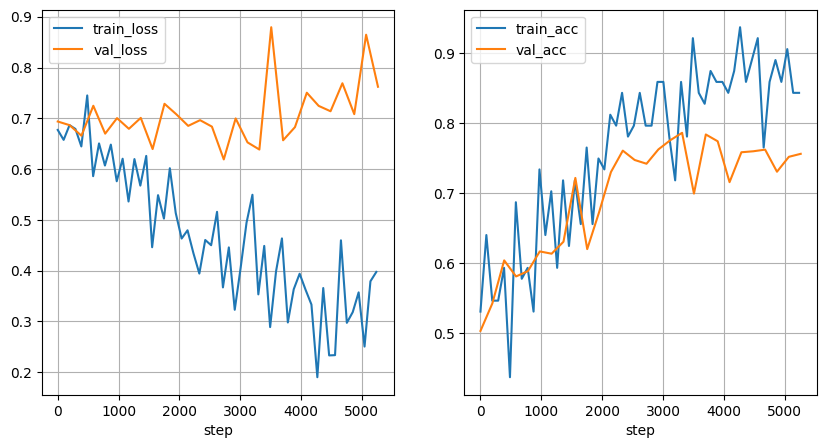

In [28]:
# 注意：损失值不限于 [0, 1] 范围，纵轴上下界由实际数值决定，不要误以为损失超界
def plot_learning_curves(record_dict, sample_step=500):
    # 参数 record_dict (dict)：training 函数返回的指标记录字典，包含 "train" 和 "val" 两个列表
    # 参数 sample_step (int)：训练曲线下采样间隔，每隔 sample_step 步取一个点，防止图像过密
    # pd.DataFrame(...).set_index("step")：将列表转为 DataFrame 并以 step 列作为索引（横坐标）
    # .iloc[::sample_step]：等间隔采样，降低训练曲线点密度，保持图表清晰
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    # 验证集评估频率较低，记录点少，无需下采样
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")

    fig_num = len(train_df.columns)   # 子图数量 = 指标列数（loss 和 acc 共 2 列）
    # plt.subplots：创建 1 行 fig_num 列的子图网格，figsize 控制整体图像宽高（英寸）
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))
    for idx, item in enumerate(train_df.columns):   # 遍历每个指标列名（"loss"、"acc"）
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")  # 绘制训练曲线
        axs[idx].plot(val_df.index, val_df[item], label=f"val_{item}")        # 绘制验证曲线
        axs[idx].grid()    # 显示网格线，便于精确读取数值
        axs[idx].legend()  # 显示图例，区分训练集和验证集曲线
        axs[idx].set_xlabel("step")  # 横轴标签为训练步数

    plt.show()  # 渲染并在 Notebook 内联显示所有子图
sample_step=eval_step//2  # 下采样间隔与训练时 eval_step 的一半对齐，避免曲线过密
plot_learning_curves(record, sample_step)

## 九、模型评估

In [29]:
# 加载训练过程中保存的最优检查点，恢复模型参数用于最终测试集评估
# torch.load：从指定路径反序列化权重文件，返回 state_dict 字典
# map_location="cpu"：强制将权重加载到 CPU，确保在无 GPU 的环境中也能正常运行
model.load_state_dict(torch.load("model_checkpoints/3_model/3_model_best.ckpt", map_location="cpu"))
# 在测试集上运行评估函数，获取最终的损失值和准确率
# 返回值：(float, float)，分别为平均损失和整体准确率
loss, acc = evaluating(model, test_dl, loss_fct)
# 格式化打印最终测试结果：:.4f 保留 4 位小数，便于与基线指标对比
print(f"loss:     {loss:.4f}\naccuracy: {acc:.4f}")

loss:     0.6385
accuracy: 0.7866
